## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load Data

In [2]:
pd.set_option('display.max_columns', None)

df = pd.read_excel('E Commerce Dataset.xlsx',sheet_name='E Comm')
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


### Data Understanding

In [3]:
print (f'Data shape: {df.shape}')

Data shape: (5630, 20)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Check and Fix Data (if necessary)

In [5]:
#check objects data dtypes
categorical_columns = df.select_dtypes(include='object')
for columns in categorical_columns:
  print(df[columns].value_counts())
  print('====================')

PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64
Gender
Male      3384
Female    2246
Name: count, dtype: int64
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


### Handle Missing Data

In [6]:
#check missing values
missing = df.isnull().sum().reset_index()
missing.columns = ['features', 'missing_values']
missing['percentage'] = (missing['missing_values']/len(df)) *100
missing

,features,missing_values,percentage
0,CustomerID,0,0.000000
1,Churn,0,0.000000
2,Tenure,264,4.689165
3,PreferredLoginDevice,0,0.000000
4,CityTier,0,0.000000
5,WarehouseToHome,251,4.458259
6,PreferredPaymentMode,0,0.000000
7,Gender,0,0.000000
8,HourSpendOnApp,255,4.529307
9,NumberOfDeviceRegistered,0,0.000000


because the missing value more than 20%, we're not going to drop them. we going to handle them to fill the missing value with median

In [7]:
# Handling missing values untuk setiap kolom

# Kolom numerik - imputasi dengan median
numerical_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                 'DaySinceLastOrder']

for col in numerical_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)
    print(f"Kolom {col}: diisi dengan median = {median_value}")

Kolom Tenure: diisi dengan median = 9.0
Kolom WarehouseToHome: diisi dengan median = 14.0
Kolom HourSpendOnApp: diisi dengan median = 3.0
Kolom OrderAmountHikeFromlastYear: diisi dengan median = 15.0
Kolom CouponUsed: diisi dengan median = 1.0
Kolom OrderCount: diisi dengan median = 2.0
Kolom DaySinceLastOrder: diisi dengan median = 3.0


/tmp/ipython-input-1195446152.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


In [8]:
# verifikasi setelah handling
print("\nMissing values setelah handling:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

# Tampilkan info dataset setelah handling missing values
print("\nInfo dataset setelah handling missing values:")
print(df.info())


Missing values setelah handling:
Series([], dtype: int64)

Info dataset setelah handling missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore           

### Handle Duplicated Data

In [9]:
#Check ratio of unique values
len(df.drop_duplicates(subset = ['CustomerID'])) / len(df)

1.0

There is no duplicated data

In [10]:
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000,5630.000000
mean,52815.500000,0.168384,10.134103,1.654707,15.566785,2.934636,3.688988,3.066785,4.214032,0.284902,15.674600,1.716874,2.961812,4.459325,177.223030
std,1625.385339,0.374240,8.357951,0.915389,8.345961,0.705528,1.023999,1.380194,2.583586,0.451408,3.591058,1.857640,2.879248,3.570626,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,3.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,15.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


###Handle Outlier

In [11]:
numeric_cols=df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [12]:
import scipy.stats as stats

def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    plt.show()

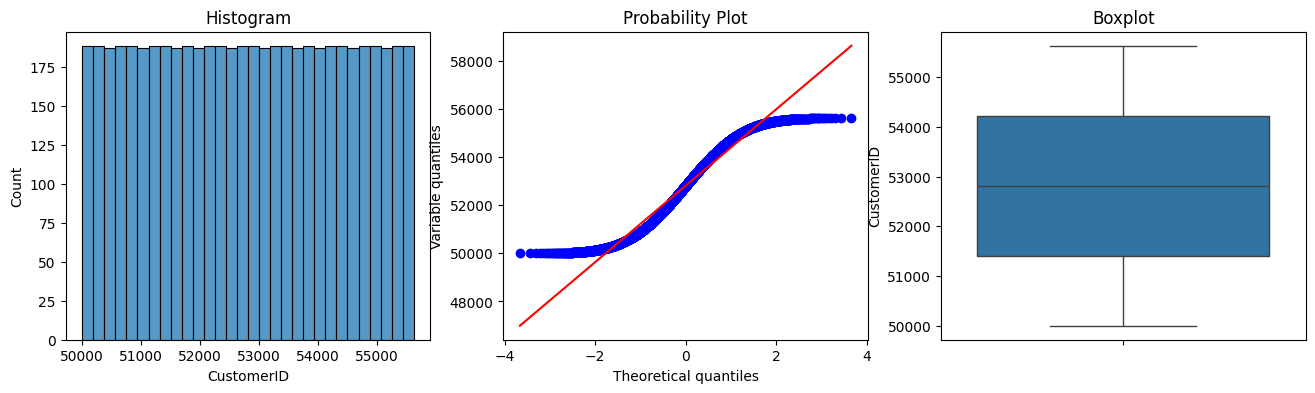

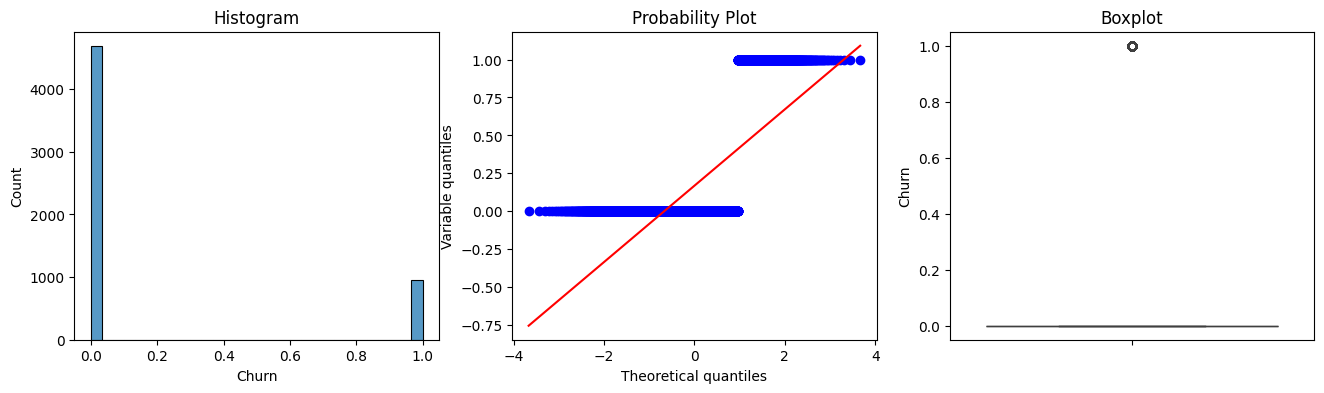

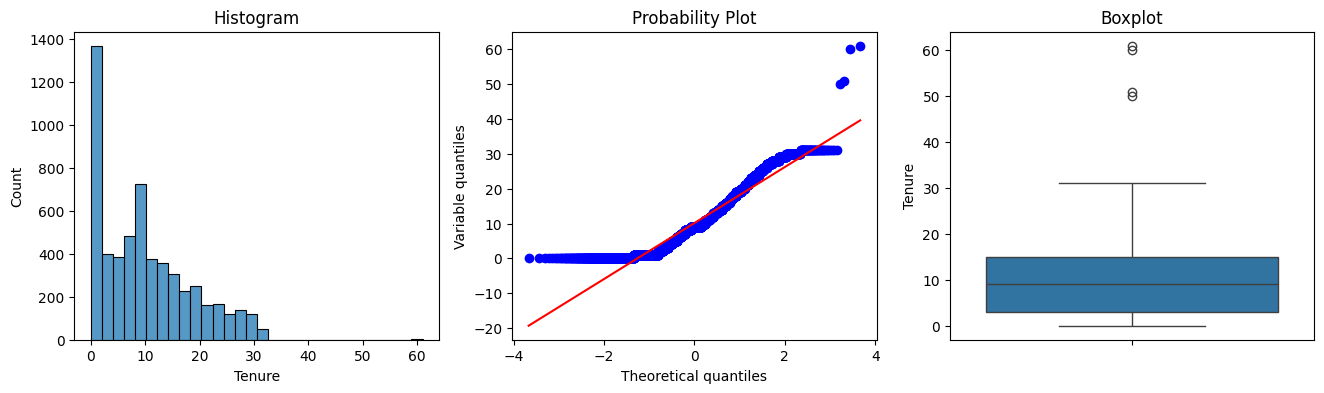

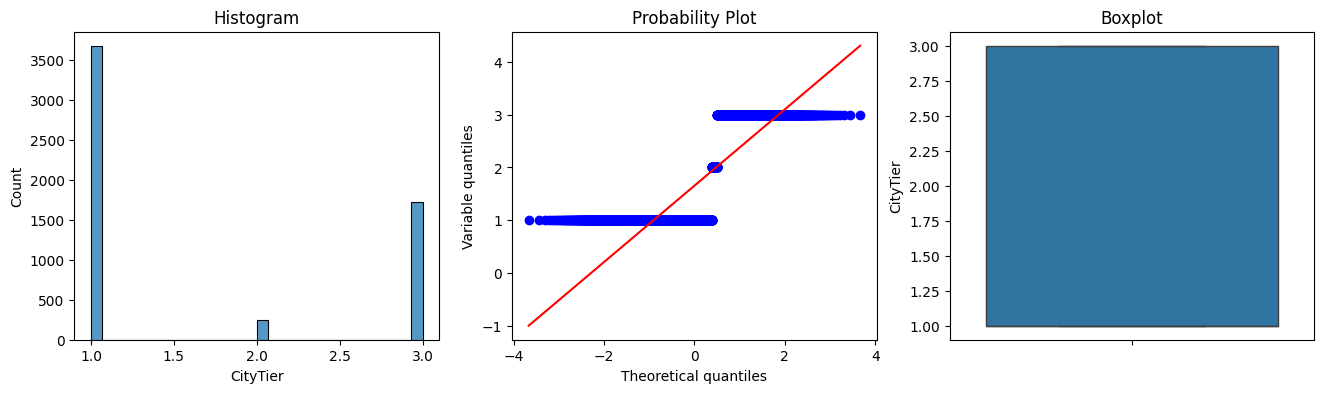

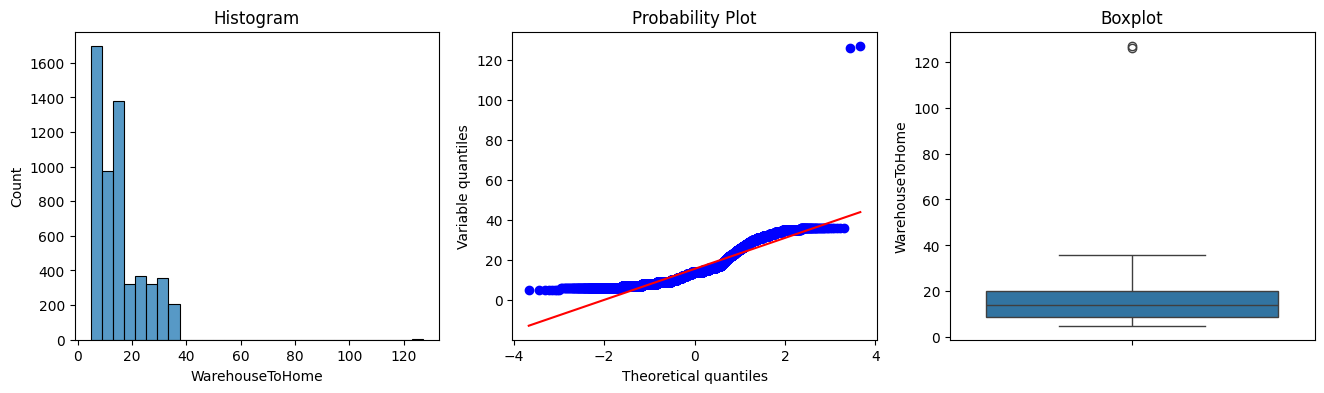

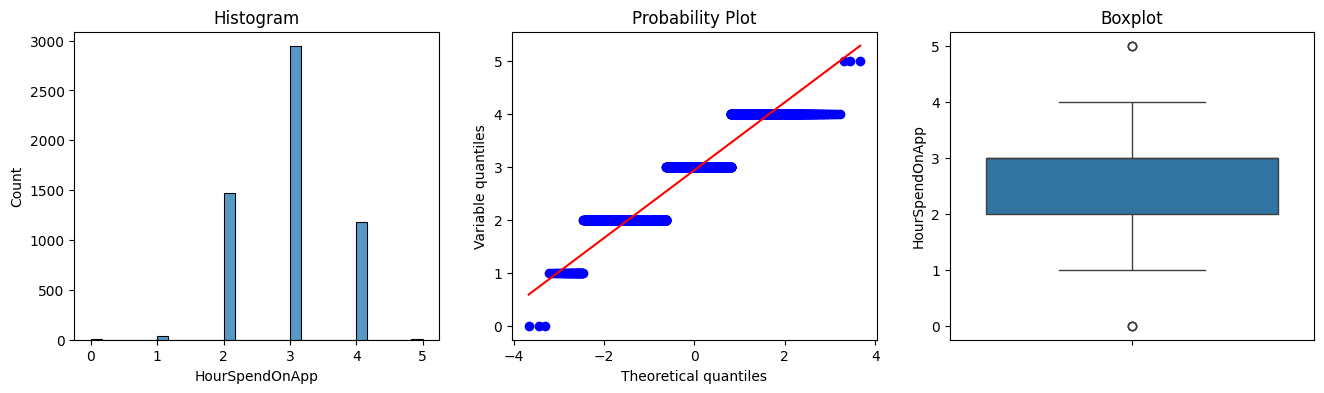

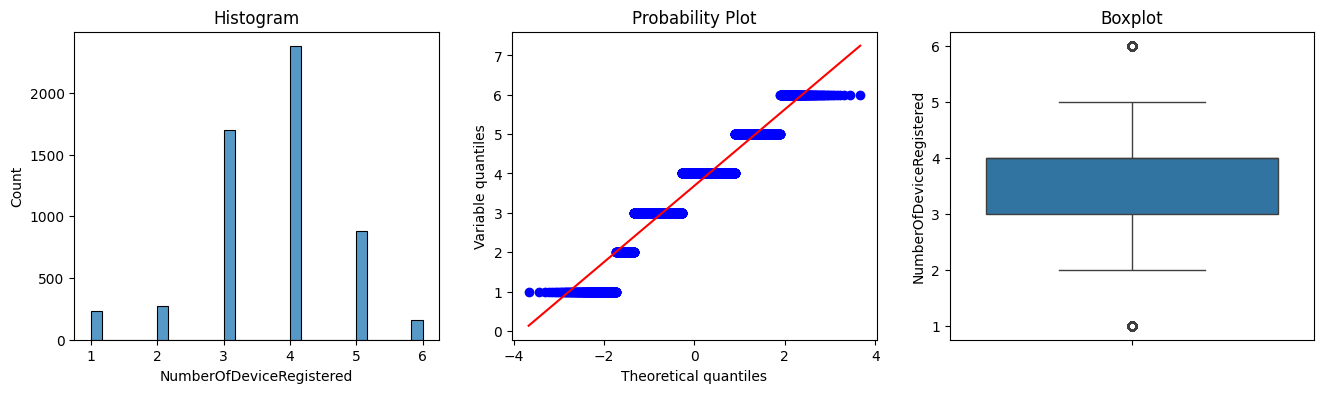

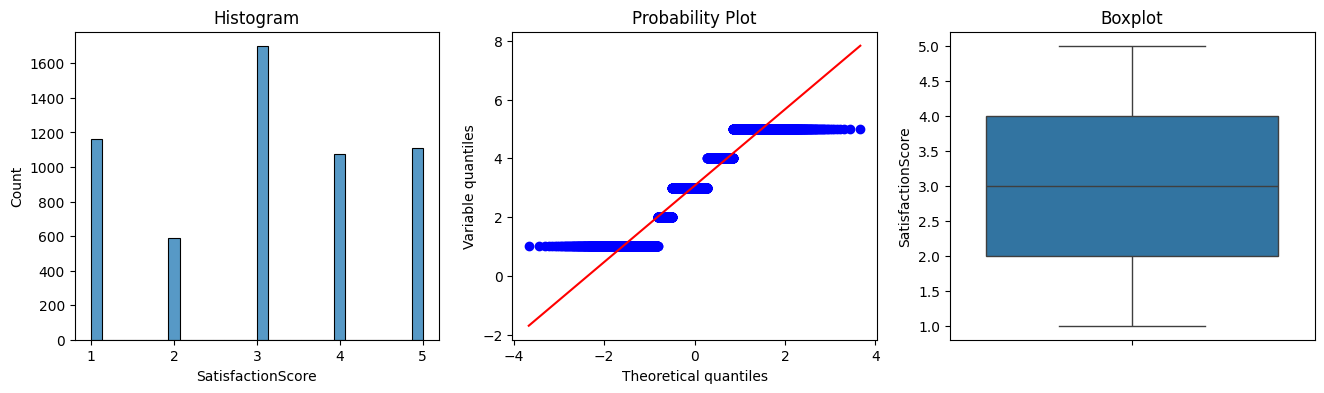

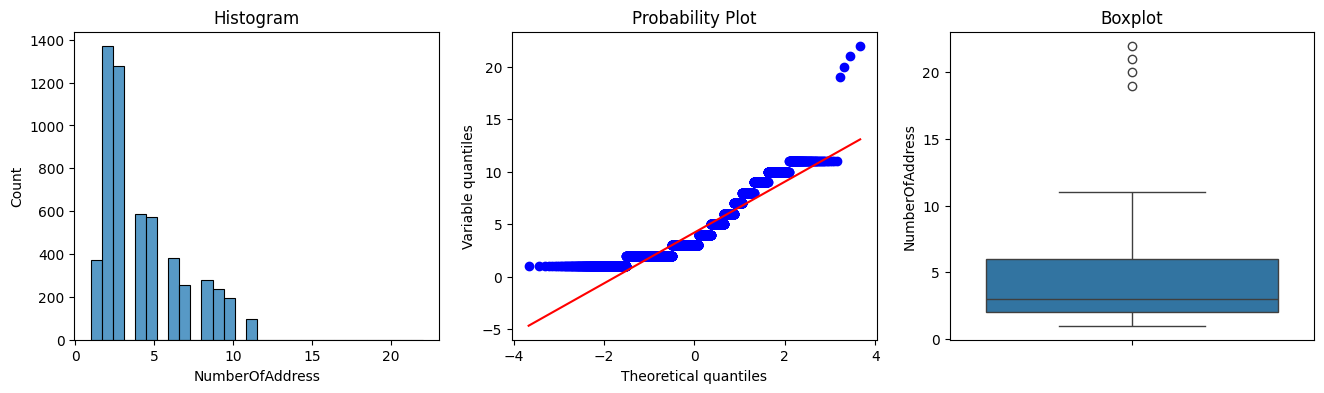

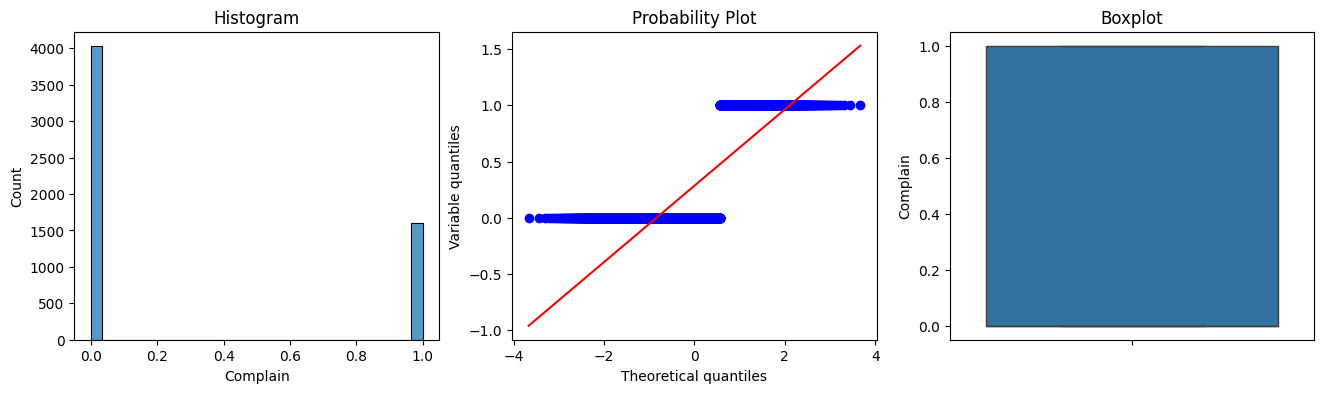

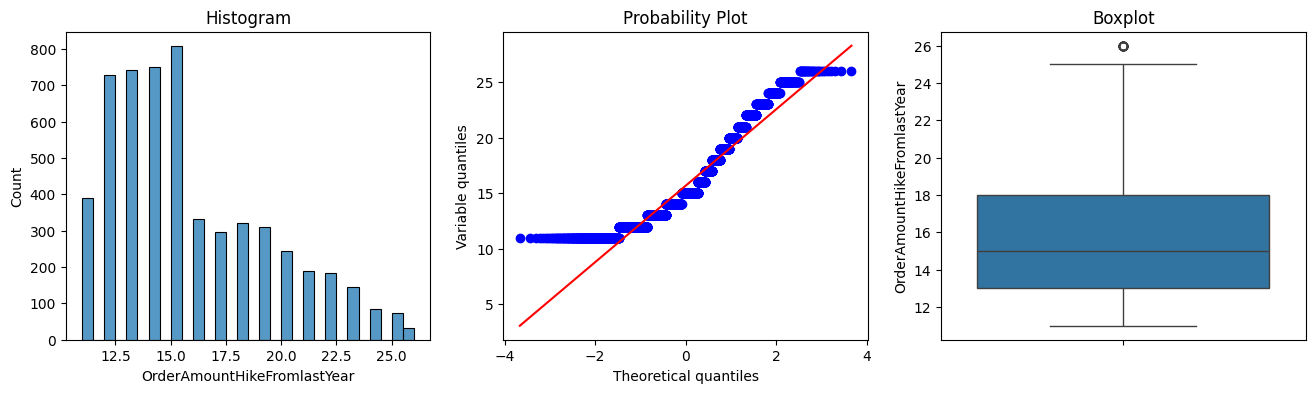

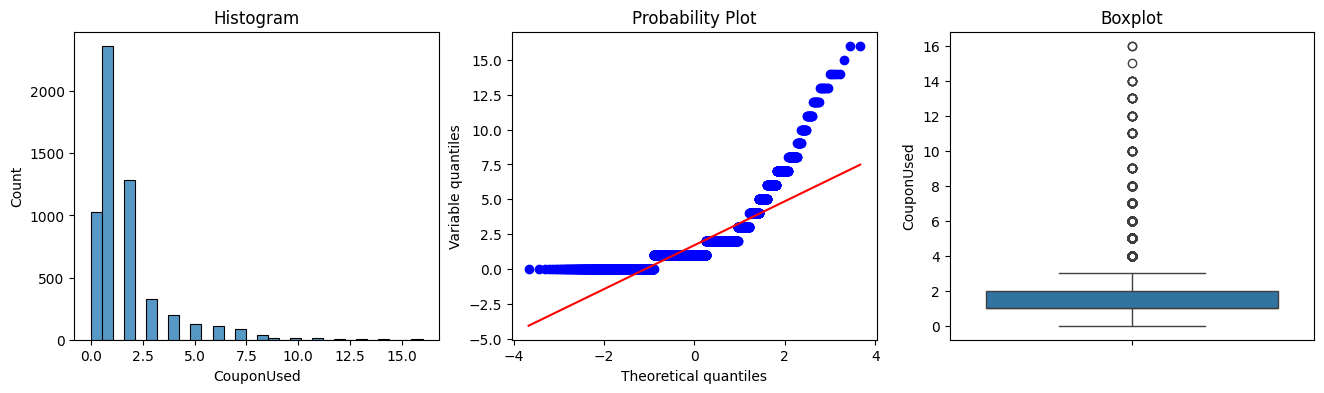

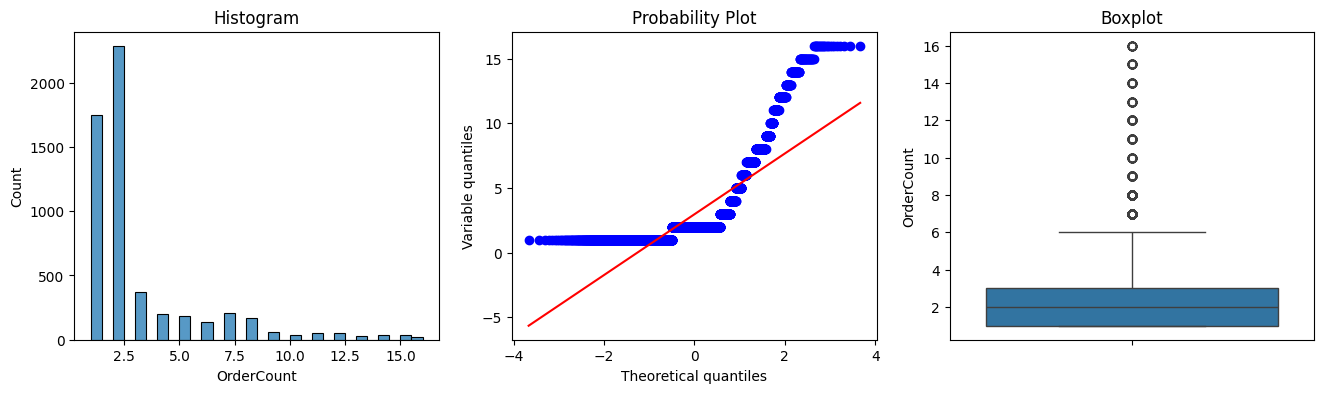

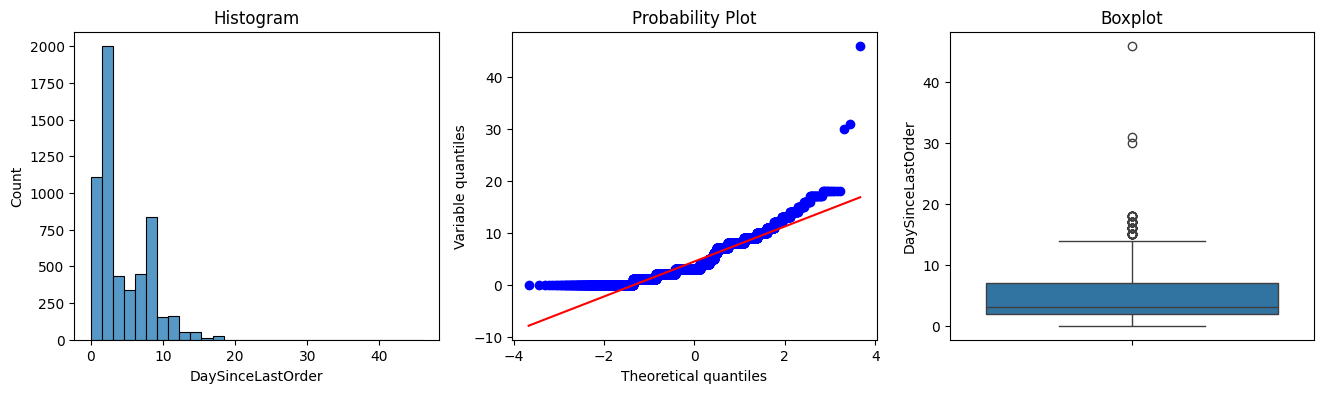

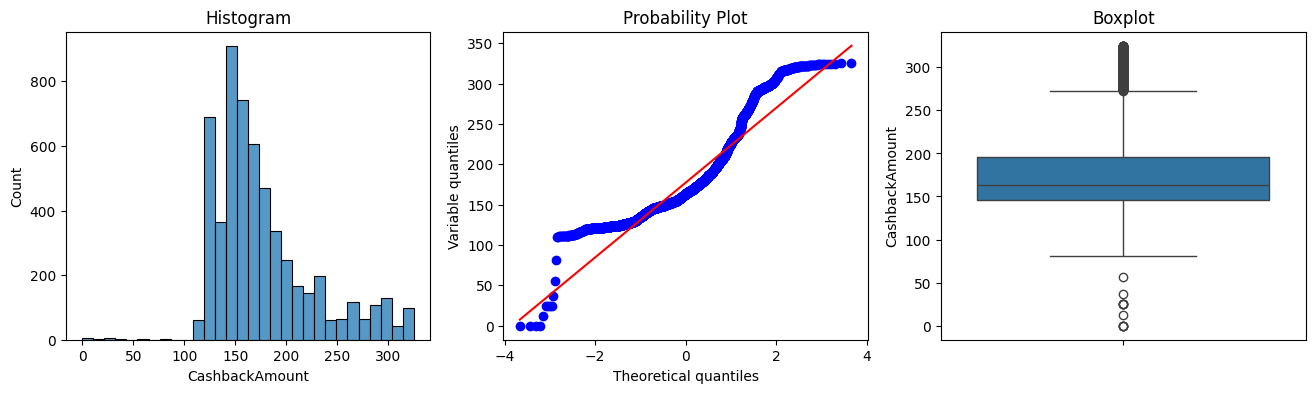

In [13]:
# Terapkan check_plot pada setiap kolom numerik
for col in numeric_cols:
    check_plot(df, col)

We had  outlier but for those coloumns the outlier are reasonable.

In [14]:
#def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

#    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

#    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
#    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

#    return upper_boundary, lower_boundary

In [15]:
# Handling outlier
#col_outlier = ['NumberOfAddress']
#for col in col_outlier:
#    upper_limit, lower_limit = find_outlier_boundary(df, col)
#    df = df[(df[col] <= upper_limit) & (df[col] >= lower_limit)]

In [16]:
# Terapkan check_plot pada setiap kolom numerik
#for col in col_outlier:
#    check_plot(df, col)

## Distribution of Churn

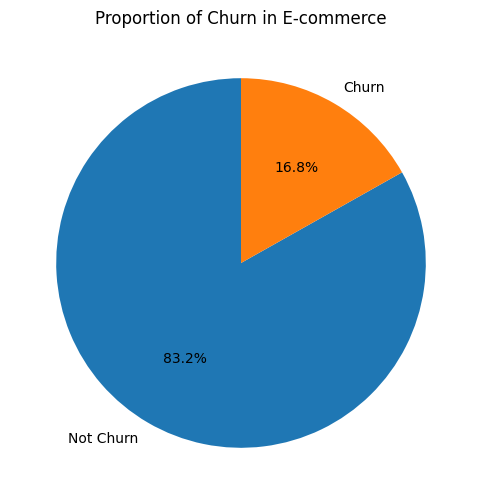

In [17]:
target_counts = df['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(target_counts, labels=['Not Churn', 'Churn'], autopct="%1.1f%%", startangle=90)
plt.title('Proportion of Churn in E-commerce')
plt.show()

**Insight**: The 16.8% customer churn rate is significant for the e-commerce business. This figure indicates that of all active customers, nearly 1 in 6 ultimately discontinues their relationship with the platform. This represents an important customer retention and revenue preservation metric that warrants deeper investigation into the underlying causes and patterns.

## Distribution of Gender on Churn

<Axes: xlabel='Churn', ylabel='count'>

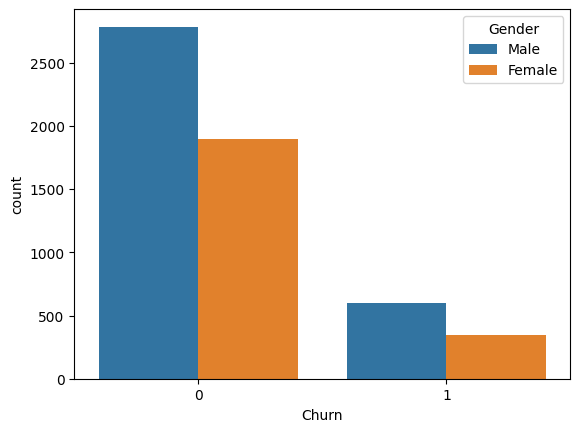

In [18]:
sns.countplot(data=df, x='Churn', hue='Gender')

**Insight**: The churn distribution by gender shows notable parity but with subtle differences worth examining. Both male and female customers demonstrate remarkably similar churn patterns, with male customers showing a slightly higher absolute number of churn instances.

## The Influence of preferred payment mode on Churn

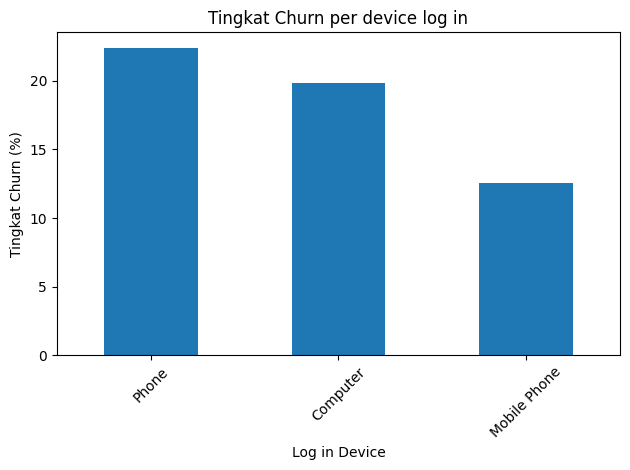

In [19]:
PreferredLoginDevice_churn = df.groupby('PreferredLoginDevice')['Churn'].mean().sort_values(ascending=False)  * 100
PreferredLoginDevice_churn.plot(kind='bar')
plt.title('Tingkat Churn per device log in')
plt.xlabel('Log in Device')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight**: The churn rate by login device reveals a significant performance gap that requires immediate attention. Phone users demonstrate a markedly higher churn rate of approximately 20-24% compared to computer users at around 20%, indicating substantial mobile experience issues.



## The Tenure VS Churn

Text(0.5, 1.0, 'Distribusi Tenure vs Churn')

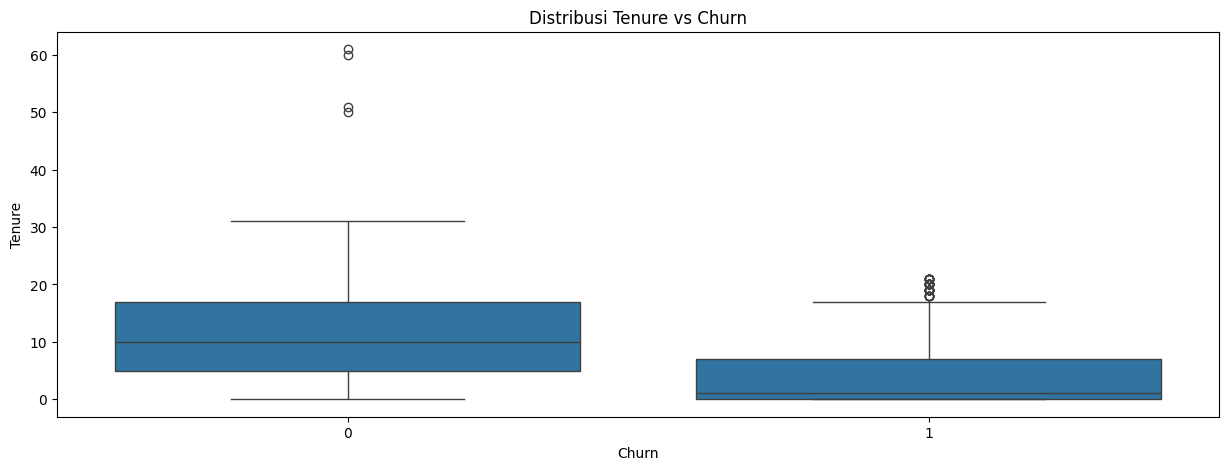

In [20]:
plt.figure(figsize=(15, 5))
sns.boxplot(x='Churn', y='Tenure', data=df)
plt.title('Distribusi Tenure vs Churn')

**Insight**: The tenure distribution between churned and retained customers reveals a critical pattern that demands strategic attention. The boxplot clearly demonstrates that customers who churn have significantly shorter tenure compared to those who remain active.

## The Preferred Payment Mode VS Churn

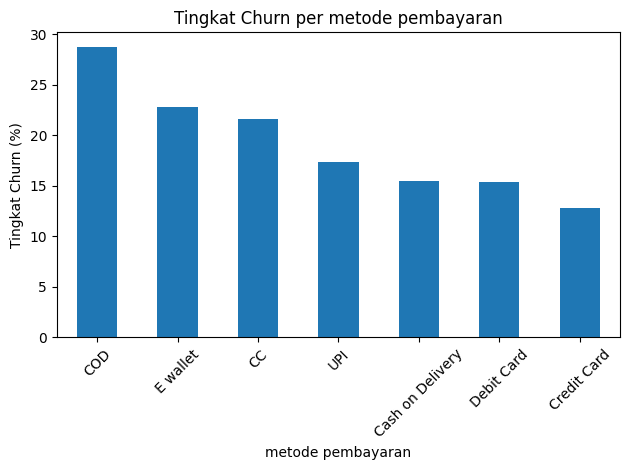

In [21]:
PreferredPaymentMode_churn = df.groupby('PreferredPaymentMode')['Churn'].mean().sort_values(ascending=False)  * 100
PreferredPaymentMode_churn.plot(kind='bar')
plt.title('Tingkat Churn per metode pembayaran')
plt.xlabel('metode pembayaran')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Insight**: The churn rate variation across payment methods reveals significant customer behavior patterns that warrant strategic optimization. Certain payment methods show markedly different churn probabilities, indicating payment experience plays a crucial role in customer retention.

Cash on Delivery: Shows the highest churn rate at approximately 28-30%, suggesting significant post-purchase dissatisfaction or impulse buying behavior

E_Wallet: Demonstrate moderate churn rates around 23-25%, indicating reasonable but improvable payment experience

Credit/Debit Cards: Exhibit the lowest churn rates at approximately 20-23%, reflecting higher customer commitment and satisfaction

## The Prefered Order Category VS Cancellation

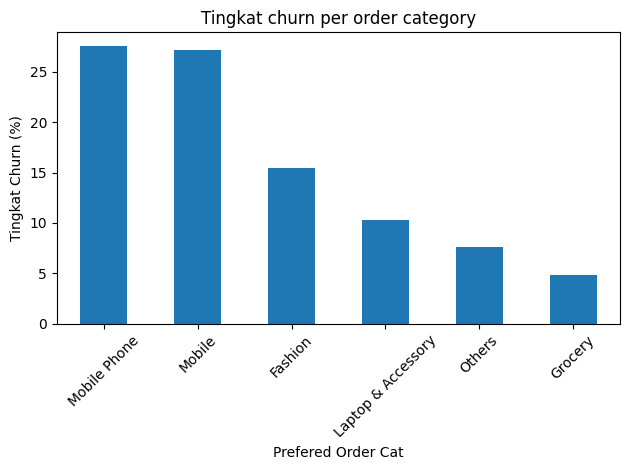

In [22]:
PreferedOrderCat_churn = df.groupby('PreferedOrderCat', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
PreferedOrderCat_churn.plot(kind='bar')
plt.title('Tingkat churn per order category')
plt.xlabel('Prefered Order Cat')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: The churn rate variation across product categories reveals dramatic differences in customer loyalty and purchasing behavior that demand category-specific strategies.

Mobile Phone Category: Alarmingly high churn rate of approximately 25-30%, indicating serious issues with customer satisfaction or competitive pressure in this segment

Fashion & Laptop/Accessory: Moderate churn rates around 9-17%, representing industry-average performance with room for improvement

Grocery Category: Exceptionally low churn rate of approximately 4-8%, demonstrating strong customer loyalty and repeat purchase behavior

## The Marital Status VS Cancellation

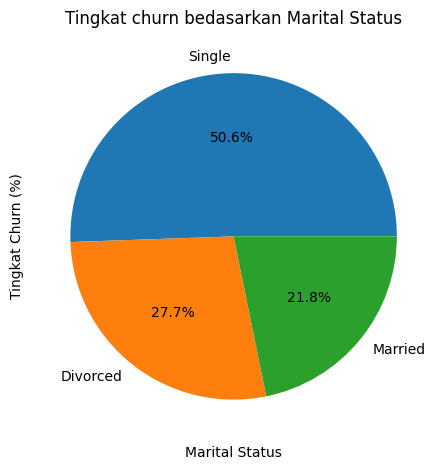

In [23]:
MaritalStatus_churn = df.groupby('MaritalStatus', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
MaritalStatus_churn.plot(kind='pie', autopct='%1.1f%%')
plt.title('Tingkat churn bedasarkan Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: The churn rate by marital status reveals dramatic disparities that demand differentiated retention strategies. Single customers demonstrate an exceptionally high churn rate of 50.6% - nearly double that of Divorce customers (27.7%) and more than twice the rate of Married customers (21.8%).

## Distribution of Complain on Churn

<Axes: xlabel='Churn', ylabel='count'>

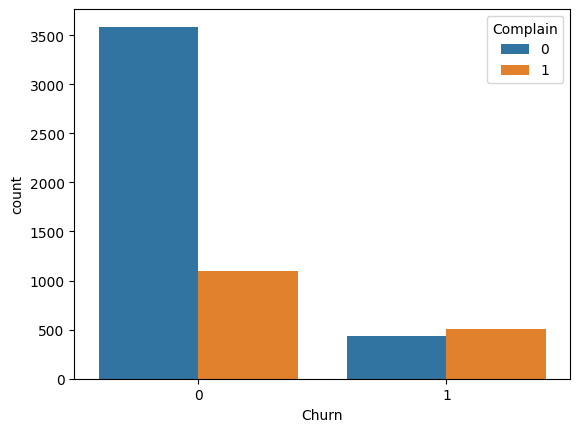

In [24]:
sns.countplot(data=df, x='Churn', hue='Complain')

**Insight**: Customers who filed complaints show an alarming churn rate that demands immediate system overhaul. The data reveals that customers with complaints (1) have approximately  higher churn probability than those without complaints (0), indicating a critical failure in complaint resolution processes.

## The Infuelnce Number of Address on Churn

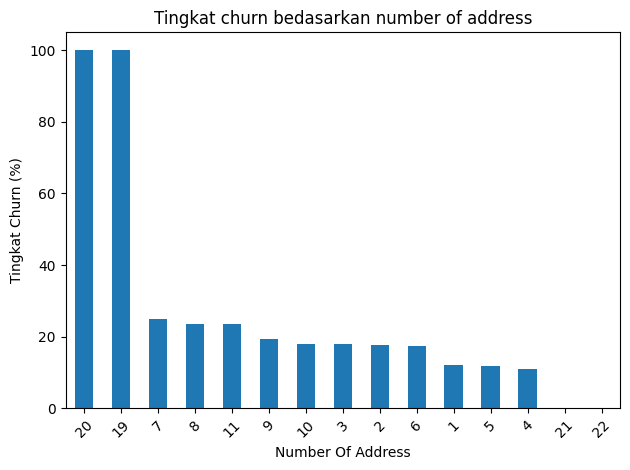

In [25]:
NumberOfAddress_churn = df.groupby('NumberOfAddress', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
NumberOfAddress_churn.plot(kind='bar')
plt.title('Tingkat churn bedasarkan number of address')
plt.xlabel('Number Of Address')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Customers with multiple addresses show significantly higher churn rates, revealing critical logistics and personalization gaps. The data indicates a clear pattern where churn probability increases substantially as the number of registered addresses grows.

## The Infuelnce CityTier on Churn

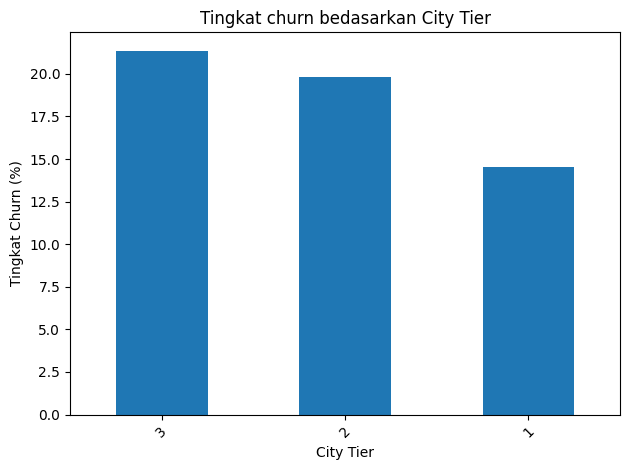

In [26]:
CityTier_churn = df.groupby('CityTier', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
CityTier_churn.plot(kind='bar')
plt.title('Tingkat churn bedasarkan City Tier')
plt.xlabel('City Tier')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Customers in Tier 3 cities demonstrate significantly higher churn rates than those in other areas, revealing critical geographic disparities in customer satisfaction. Tier 3 city residents show approximately more than 20% churn rate.

## The Infuelnce Number Of Device Registered on Churn

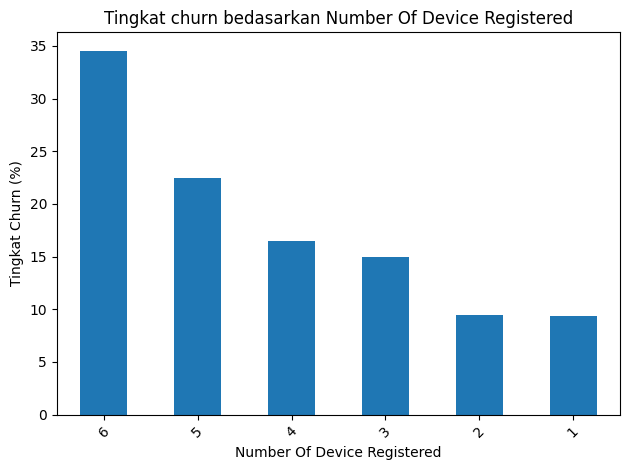

In [27]:
NumberOfDeviceRegistered_churn = df.groupby('NumberOfDeviceRegistered', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
NumberOfDeviceRegistered_churn.plot(kind='bar')
plt.title('Tingkat churn bedasarkan Number Of Device Registered')
plt.xlabel('Number Of Device Registered')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Customers with multiple registered devices show dramatically higher churn rates, revealing critical platform integration and user experience issues. The data indicates a clear correlation where churn probability increases exponentially with each additional registered device.

## The Cashback Amount VS Churn

Text(0.5, 1.0, 'Distribusi Cashback Amount vs Churn')

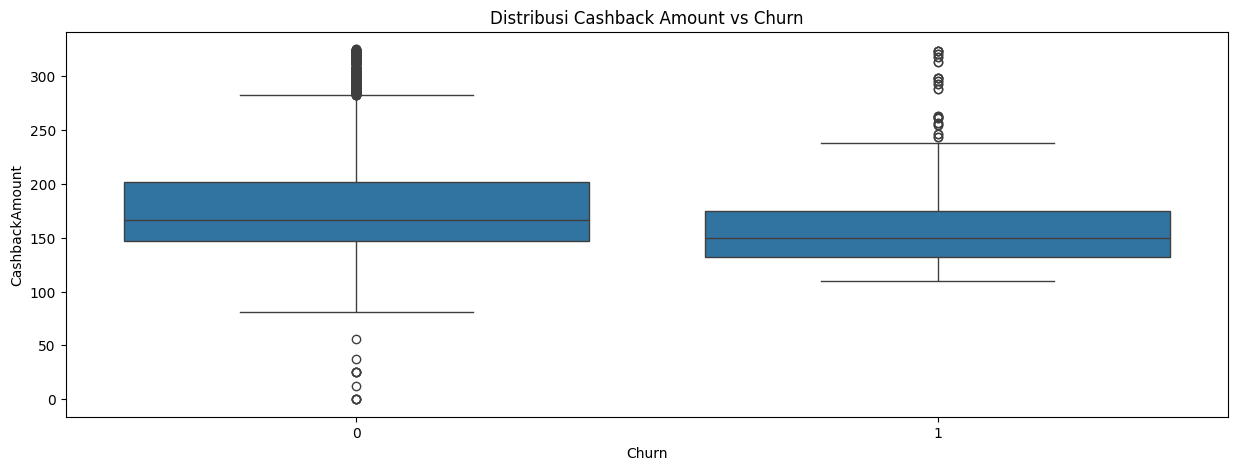

In [28]:
plt.figure(figsize=(15, 5))
sns.boxplot(x='Churn', y='CashbackAmount', data=df)
plt.title('Distribusi Cashback Amount vs Churn')

**Insight**: Customers receiving lower cashback amounts demonstrate significantly higher churn rates, revealing a critical relationship between reward value and customer loyalty. The data shows a clear inverse correlation where churn probability decreases as cashback amounts increase.

## Satisfaction Score VS Churn

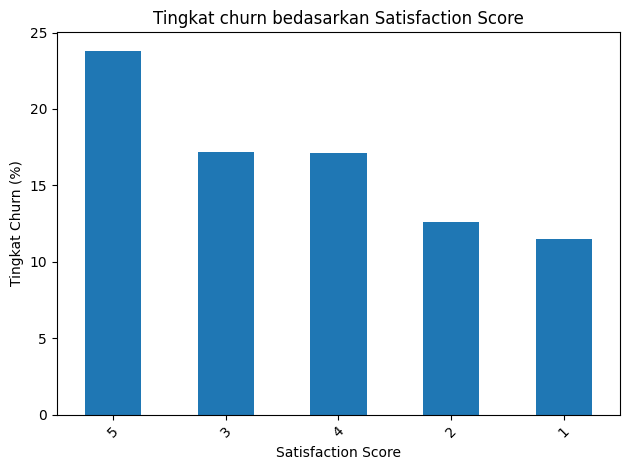

In [29]:
SatisfactionScore_churn = df.groupby('SatisfactionScore', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
SatisfactionScore_churn.plot(kind='bar')
plt.title('Tingkat churn bedasarkan Satisfaction Score')
plt.xlabel('Satisfaction Score')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Customers with satisfaction scores 5 demonstrate catastrophic churn rates.

## The Hour Spend On App VS Churn

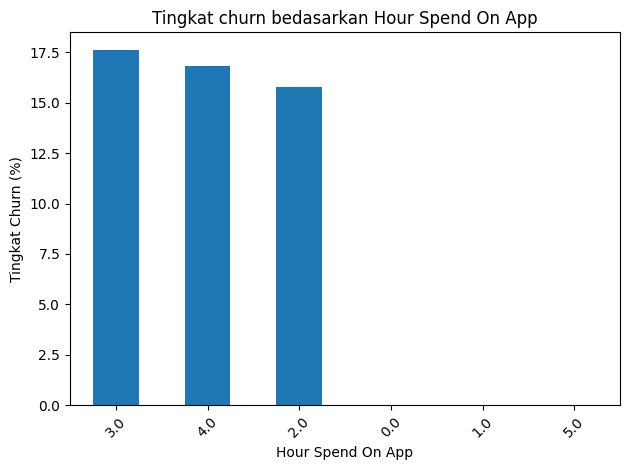

In [30]:
HourSpendOnApp_churn = df.groupby('HourSpendOnApp', observed=True)['Churn'].mean().sort_values(ascending=False) * 100

# Plot
HourSpendOnApp_churn.plot(kind='bar')
plt.title('Tingkat churn bedasarkan Hour Spend On App')
plt.xlabel('Hour Spend On App')
plt.ylabel('Tingkat Churn (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**:Customers with 3 hours app engagement demonstrate significantly higher churn rate.

## Practical Recommendations to Reduce Customer Churn

**1. Understanding Our Customers**

**New vs. Established Customers:** Our newer customers (0-2 years tenure) cancel 3x more often than loyal customers. This suggests the first two years are critical for building commitment. We should create a "welcome journey" program with progressive rewards and personalized check-ins during this vulnerable period. For our established customers (4+ years), they're already quite loyal, so we can focus on maintaining their satisfaction.

**Single vs. Married Customers:** Single customers cancel twice as often as married customers. This might be because they have less stable routines or more flexibility to switch platforms. For single customers, we could develop more flexible loyalty programs and social engagement features. For married customers, family-focused benefits and shared account features seem to be working well.

**2. Platform Experience & Engagement**

**App Engagement:** Customers who spend less than 1 hour on our app are 6x more likely to leave. We need to make the app more engaging with personalized content, gamified features, and exclusive mobile-only deals. The sweet spot appears to be 3 hours of usage, where retention improves dramatically.

**Multi-Device Users:** Surprisingly, customers with 3+ registered devices cancel more often. This might indicate synchronization problems or security concerns. We should improve cross-device experience and provide better device management tools.

**3. Payment & Value Strategies**

**Payment Methods:** Cash on Delivery users cancel more than credit card users. We should gently nudge customers toward digital payments with small incentives while improving the COD experience with better delivery confirmation and tracking.

**Cashback Strategy:** Lower cashback amounts (below 50) correlate with higher churn. We might want to restructure our rewards to ensure most customers reach at least the 100-150 cashback threshold where retention improves significantly. The data suggests cashback is working well as a retention tool for engaged customers.

**4. Product Category Management**

**High-Risk Categories:** Mobile phone buyers cancel more than grocery shoppers. This is concerning since mobile phones are high-value items. We should investigate why - perhaps quality concerns, competitive pricing, or delivery issues. For this category, we might introduce extended warranties, price protection, and enhanced quality checks.

**Stable Categories:** Our grocery category shows excellent retention. We should study what makes these customers so loyal and apply those lessons to other categories. Maybe introducing subscription models or personalized replenishment reminders would work well.

**5. Geographic Strategy**

**City Tier Differences:** The data shows satisfaction scores below 3 are essentially customer departure warnings. We should implement real-time alerts for low satisfaction scores and proactive service recovery.

**6. Service Recovery & Satisfaction**

**Complaint Resolution:** Customers who file complaints have a devastating 85-90% churn rate. This is our biggest opportunity for improvement. We need an emergency response system for complaints - perhaps 24-hour resolution guarantees and executive follow-up for serious issues.

**Satisfaction Monitoring:** The data shows satisfaction scores up 3 are essentially customer departure warnings. We should implement real-time alerts for low satisfaction scores and proactive service recovery before these customers decide to leave.

**7. Overall Approach**

**Priority Focus:** Given the geographic pattern, we should immediately investigate why Tier 3 cities underperform and develop region-specific solutions.

**Early Warning System:** Creating a churn prediction score combining tenure, satisfaction, engagement, and purchase patterns could help us identify at-risk customers before they leave.

**Segment-Specific Strategies:** Rather than one-size-fits-all, we need different approaches for different customer types - new vs. established, single vs. married, mobile vs. grocery shoppers.

**Continuous Feedback:** Regular customer satisfaction monitoring and quick response to issues will be crucial. The data shows that once satisfaction drops below 3, recovery becomes very difficult.

The key insight is that churn prevention requires understanding different customer journeys and addressing their specific pain points. By focusing on the first two years, improving complaint resolution, and tailoring our approach to different customer segments, we can significantly improve retention across the board.

In [31]:
df.to_csv('EDA_cleaned.csv', index=False)